# Interpretability — SHAP & LIME

This notebook applies two explainability methods to the trained U-Net segmentation model:

- **SHAP** (GradientExplainer): pixel-level gradient-based attributions showing which input regions drive the model's predictions.
- **LIME** (LimeImageExplainer): superpixel-based perturbation approach showing which image segments contribute most to the predicted tumor region.

Both methods help understand *why* the model segments a region as tumor.

In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries


def _find_root(marker="dataset.py"):
    d = os.path.abspath(os.getcwd())
    while d != os.path.dirname(d):
        if os.path.exists(os.path.join(d, marker)):
            return d
        d = os.path.dirname(d)
    return os.path.abspath(os.getcwd())


BASE_DIR = _find_root()
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from dataset import BrainTumorDataset
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
from model import UNet

model = UNet().to(device)

unet_path = os.path.join(BASE_DIR, "models", "unet.pt")
model.load_state_dict(torch.load(unet_path, map_location=device))
model.eval()
print(f"U-Net weights loaded from {unet_path}")


U-Net weights loaded from /root/mlp/models/unet.pt


In [3]:
import importlib
import dataset as dataset_module
importlib.reload(dataset_module)
from dataset import BrainTumorDataset

BASE_DIR = _find_root()

dataset = BrainTumorDataset(
    image_dir=os.path.join(BASE_DIR, "data/processed/images"),
    mask_dir=os.path.join(BASE_DIR, "data/processed/masks"),
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
batch_images, batch_masks = next(iter(val_loader))
batch_images = batch_images.to(device)
batch_masks = batch_masks.to(device)

n_samples = 4
areas = batch_masks.sum(dim=[1, 2, 3])
order = torch.argsort(areas, descending=True)
test_idx = order[:n_samples]
bg_idx = order[n_samples:n_samples + 20]

test_images = batch_images[test_idx]
test_masks = batch_masks[test_idx]
background = batch_images[bg_idx]

print(f"Dataset: {len(dataset)} samples | Train: {train_size} | Val: {val_size}")
print(f"Explaining {n_samples} largest-tumor samples | background images: {background.shape[0]}")
print("Tumor pixel areas (test):", test_masks.sum(dim=[1, 2, 3]).int().tolist())

Dataset: 3064 samples | Train: 2451 | Val: 613
Explaining 4 largest-tumor samples | background images: 20
Tumor pixel areas (test): [3233, 2470, 1661, 1614]


## SHAP — Gradient-Based Pixel Attribution

`shap.GradientExplainer` computes expected gradients of the model output with respect to the input, relative to a background set. To keep the explanation focused on the tumor, the model output is summarised as the **mean predicted probability inside the predicted tumor region** (rather than the whole-image mean, which is dominated by background and dilutes the attributions).

Positive values (red) increase the predicted tumor score; negative (blue) suppress it. The green contour marks the model's predicted tumor boundary.

In [4]:
class UNetTumorScore(nn.Module):
    """Scalar output = mean predicted probability inside the predicted tumor
    region. This concentrates attribution on the tumor instead of the
    whole-image mean (which is dominated by background)."""

    def __init__(self, unet):
        super().__init__()
        self.unet = unet

    def forward(self, x):
        seg = self.unet(x)
        gate = (seg > 0.5).float()
        score = (seg * gate).sum(dim=[1, 2, 3]) / (gate.sum(dim=[1, 2, 3]) + 1e-6)
        return score.unsqueeze(1)


scalar_model = UNetTumorScore(model).to(device)
scalar_model.eval()

explainer = shap.GradientExplainer(scalar_model, background)
shap_values = explainer.shap_values(test_images)
shap_arr = np.array(shap_values)

print("SHAP values shape:", shap_arr.shape)
print("n_samples:", n_samples)

SHAP values shape: (4, 3, 256, 256, 1)
n_samples: 4


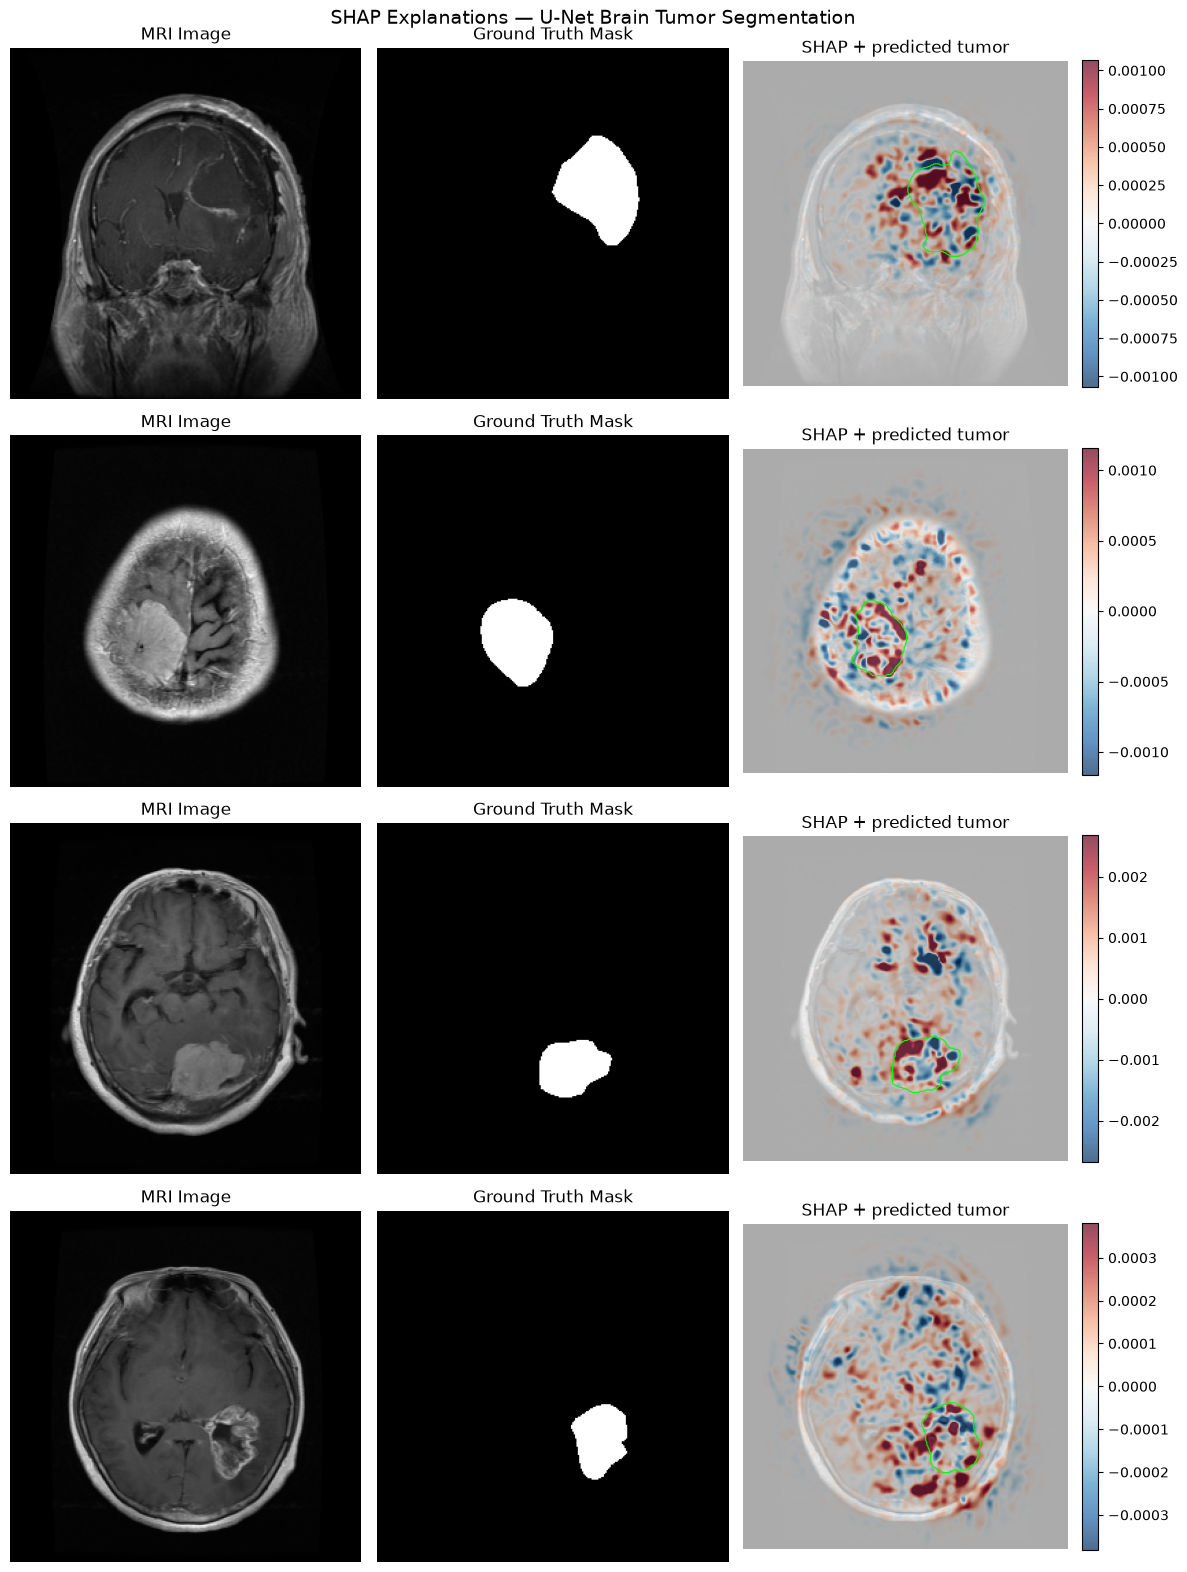

SHAP plot saved.


In [5]:
from scipy.ndimage import gaussian_filter

model.eval()
with torch.no_grad():
    pred_probs = model(test_images).cpu().numpy()

fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 4))

for i in range(n_samples):
    img_np = test_images[i].cpu().permute(1, 2, 0).numpy()
    mask_np = test_masks[i].cpu().squeeze().numpy()
    shap_map = shap_arr[i, :, :, :, 0].sum(axis=0)
    shap_map = gaussian_filter(shap_map, sigma=2.0)
    vmax = np.percentile(np.abs(shap_map), 99) + 1e-12

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("MRI Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img_np)
    im = axes[i, 2].imshow(shap_map, cmap="RdBu_r", alpha=0.7, vmin=-vmax, vmax=vmax)
    axes[i, 2].contour(pred_probs[i, 0], levels=[0.5], colors="lime", linewidths=0.8)
    axes[i, 2].set_title("SHAP + predicted tumor")
    axes[i, 2].axis("off")
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.suptitle("SHAP Explanations — U-Net Brain Tumor Segmentation", fontsize=14)
plt.tight_layout()
os.makedirs(os.path.join(BASE_DIR, "reports"), exist_ok=True)
plt.savefig(os.path.join(BASE_DIR, "reports/shap_explanation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("SHAP plot saved.")

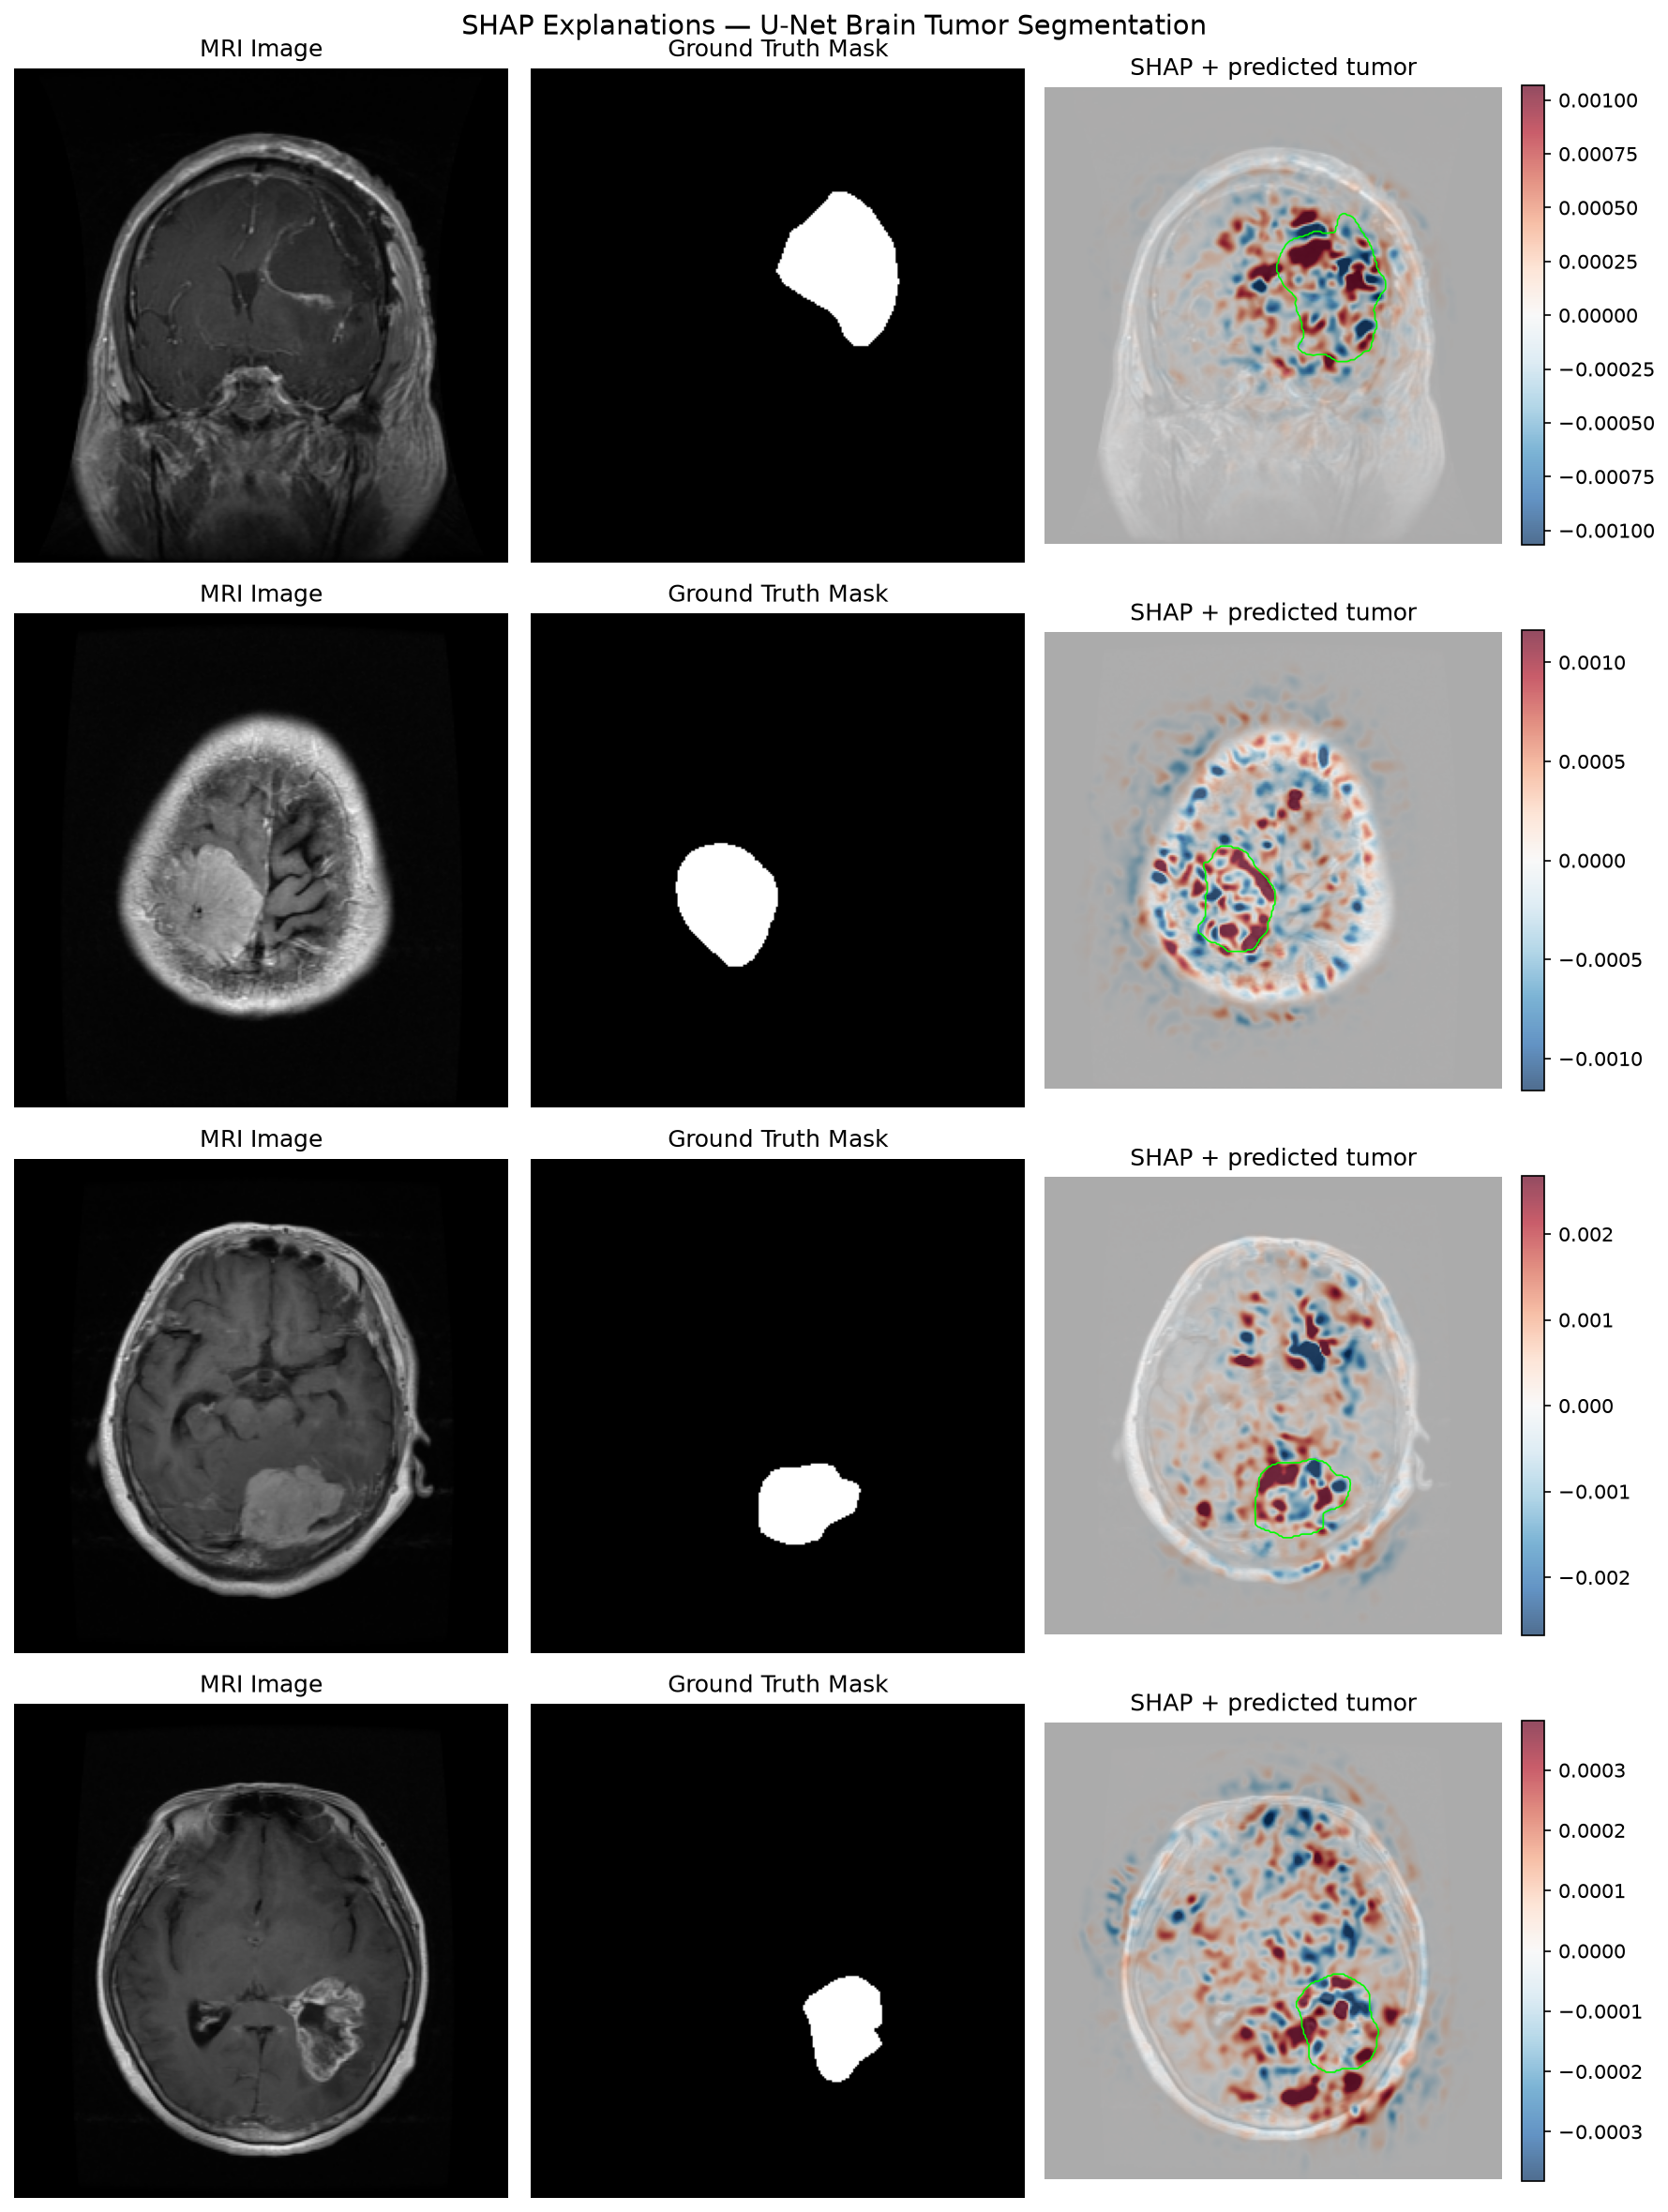

In [6]:
from IPython.display import Image, display
display(Image(filename=os.path.join(BASE_DIR, "reports/shap_explanation.png")))

## LIME — Superpixel Perturbation Analysis

`LimeImageExplainer` perturbs groups of pixels (superpixels) and measures the change in the model's tumor score (mean probability inside the predicted tumor region). Superpixels that most increase the tumor score — i.e., the regions the model relies on — are highlighted (1000 perturbation samples per image).

In [7]:
def lime_predict(images_np):
    batch = torch.tensor(images_np, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    with torch.no_grad():
        seg = model(batch)
        gate = (seg > 0.5).float()
        tumor_score = (seg * gate).sum(dim=[1, 2, 3]) / (gate.sum(dim=[1, 2, 3]) + 1e-6)
    tumor_score = tumor_score.cpu().numpy()
    return np.stack([1.0 - tumor_score, tumor_score], axis=1)


explainer_lime = lime_image.LimeImageExplainer()

lime_explanations = []
for i in range(n_samples):
    img_np = test_images[i].cpu().permute(1, 2, 0).numpy().astype(np.float64)
    explanation = explainer_lime.explain_instance(
        img_np,
        lime_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000,
    )
    lime_explanations.append(explanation)
    print(f"LIME explanation {i+1}/{n_samples} done.")

  0%|          | 0/1000 [00:00<?, ?it/s]

LIME explanation 1/4 done.


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME explanation 2/4 done.


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME explanation 3/4 done.


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME explanation 4/4 done.


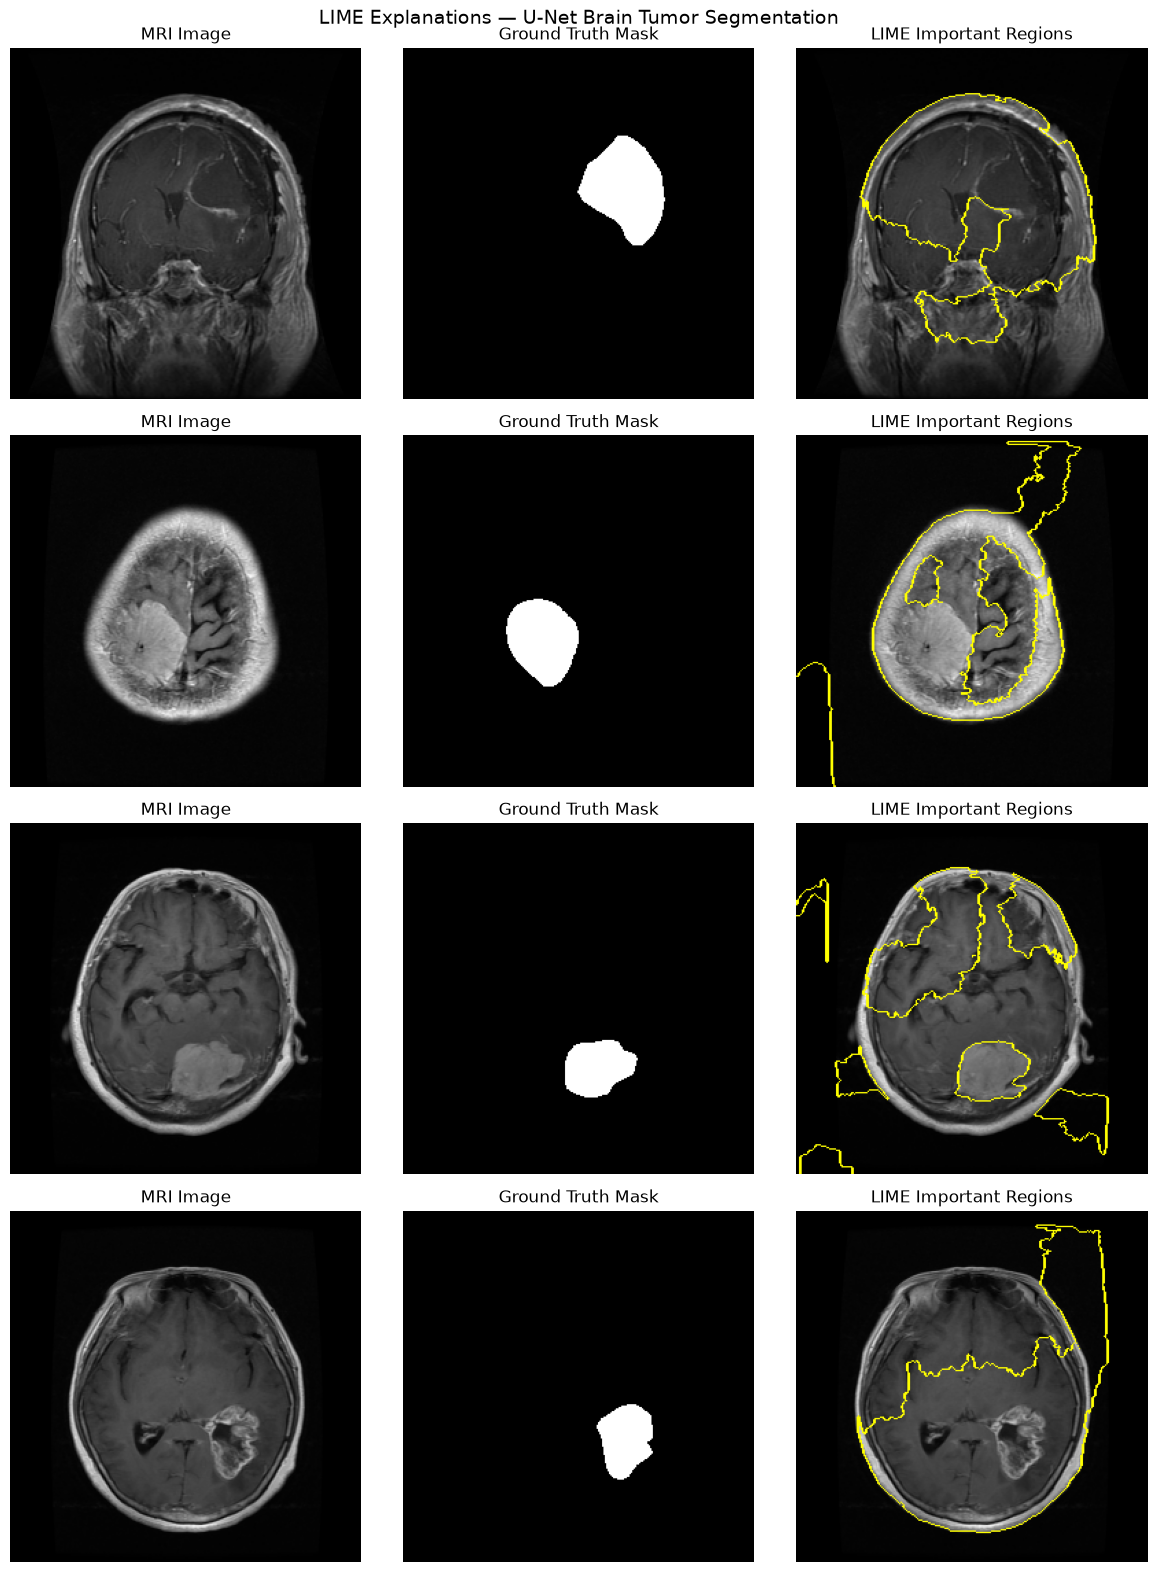

LIME plot saved to reports/lime_explanation.png


In [8]:
fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 4))

for i in range(n_samples):
    img_np = test_images[i].cpu().permute(1, 2, 0).numpy()
    mask_np = test_masks[i].cpu().squeeze().numpy()
    exp = lime_explanations[i]

    top_label = exp.top_labels[0]
    temp, lime_mask = exp.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=8,
        hide_rest=False,
    )

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("MRI Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mark_boundaries(temp, lime_mask))
    axes[i, 2].set_title("LIME Important Regions")
    axes[i, 2].axis("off")

plt.suptitle("LIME Explanations — U-Net Brain Tumor Segmentation", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports/lime_explanation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("LIME plot saved to reports/lime_explanation.png")

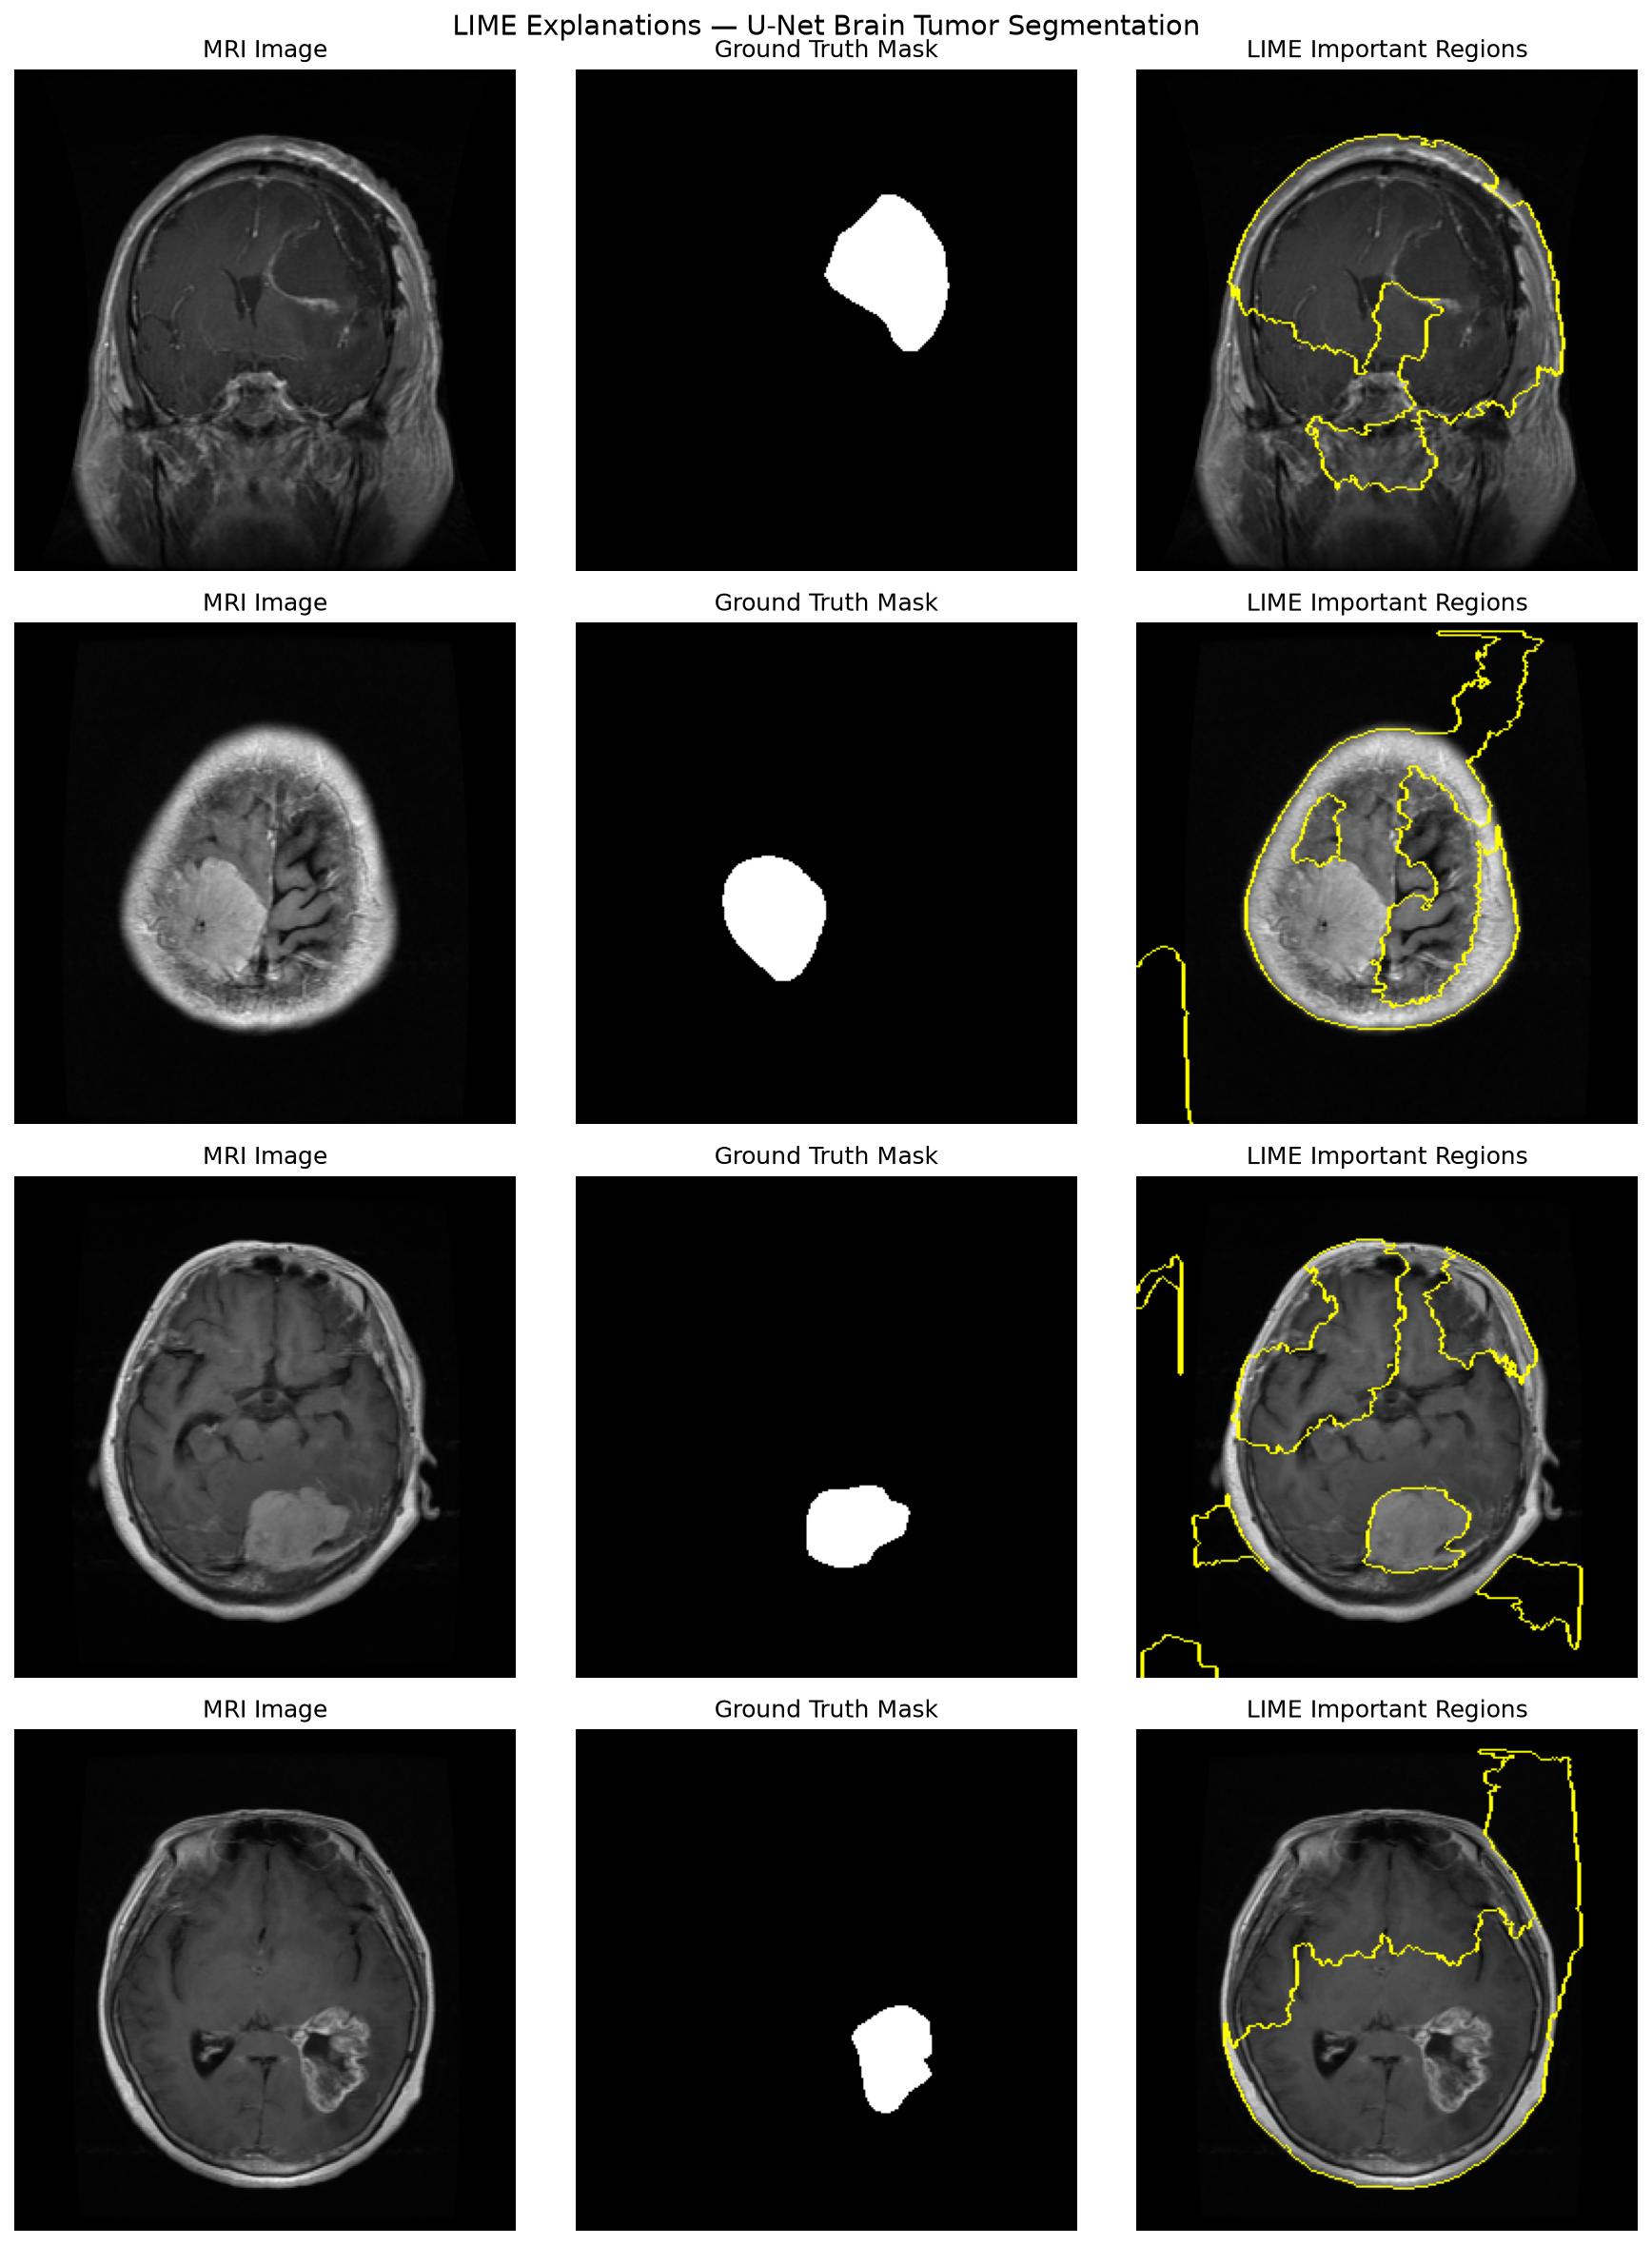

In [9]:
display(Image(filename=os.path.join(BASE_DIR, "reports/lime_explanation.png")))

## SHAP vs LIME — Side-by-Side Comparison

Both methods are shown together for the same samples so their explanations can be directly compared.

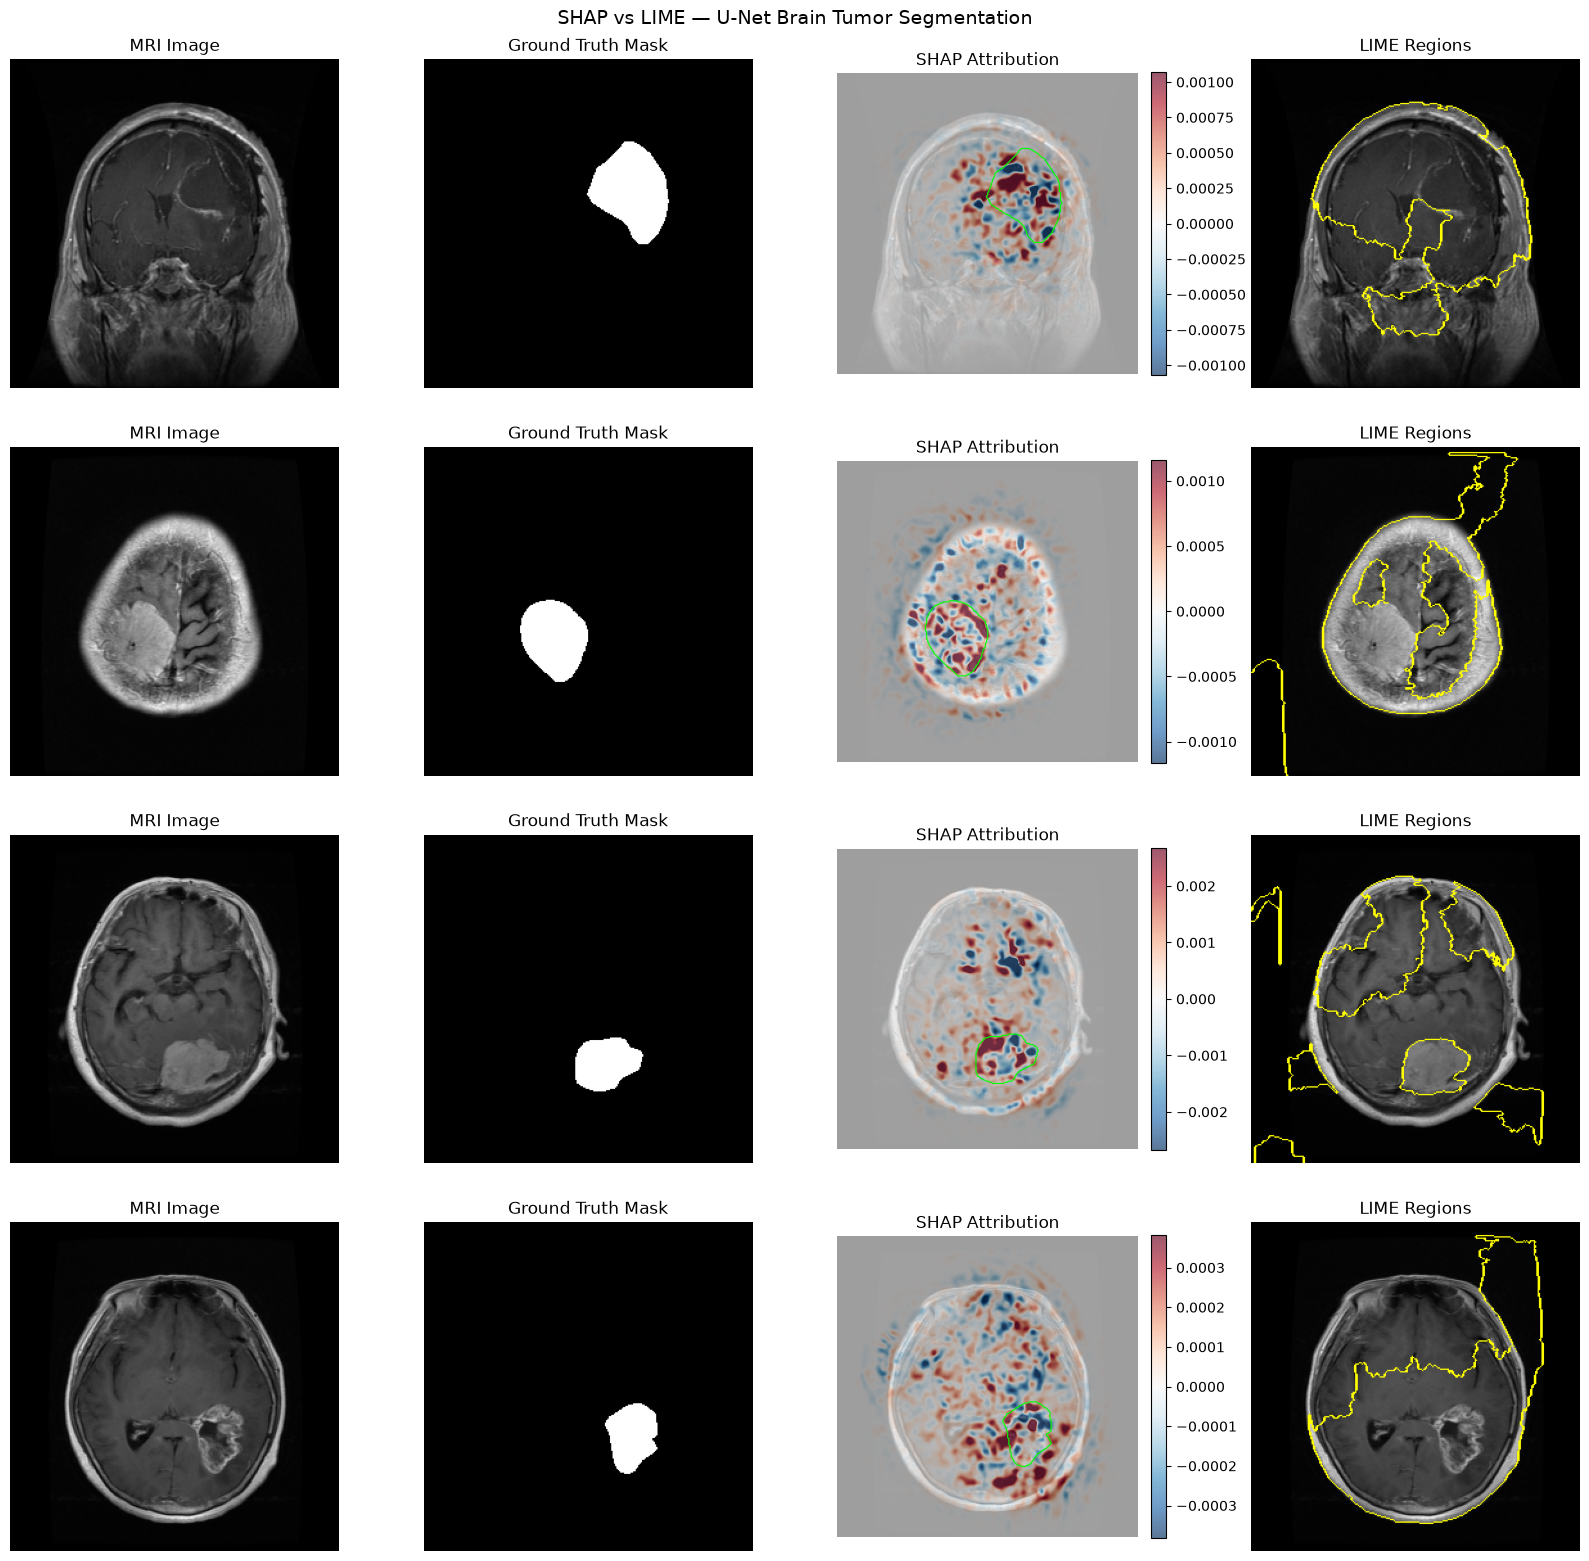

Comparison plot saved to reports/shap_vs_lime.png


In [10]:
from scipy.ndimage import gaussian_filter

fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 4))

for i in range(n_samples):
    img_np = test_images[i].cpu().permute(1, 2, 0).numpy()
    mask_np = test_masks[i].cpu().squeeze().numpy()
    shap_map = gaussian_filter(shap_arr[i, :, :, :, 0].sum(axis=0), sigma=2.0)
    vmax = np.percentile(np.abs(shap_map), 99) + 1e-12

    exp = lime_explanations[i]
    top_label = exp.top_labels[0]
    temp, lime_mask = exp.get_image_and_mask(
        top_label, positive_only=True, num_features=8, hide_rest=False
    )

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("MRI Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img_np)
    im = axes[i, 2].imshow(shap_map, cmap="RdBu_r", alpha=0.65, vmin=-vmax, vmax=vmax)
    axes[i, 2].contour(mask_np, levels=[0.5], colors="lime", linewidths=0.8)
    axes[i, 2].set_title("SHAP Attribution")
    axes[i, 2].axis("off")
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    axes[i, 3].imshow(mark_boundaries(temp, lime_mask))
    axes[i, 3].set_title("LIME Regions")
    axes[i, 3].axis("off")

plt.suptitle("SHAP vs LIME — U-Net Brain Tumor Segmentation", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports/shap_vs_lime.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Comparison plot saved to reports/shap_vs_lime.png")

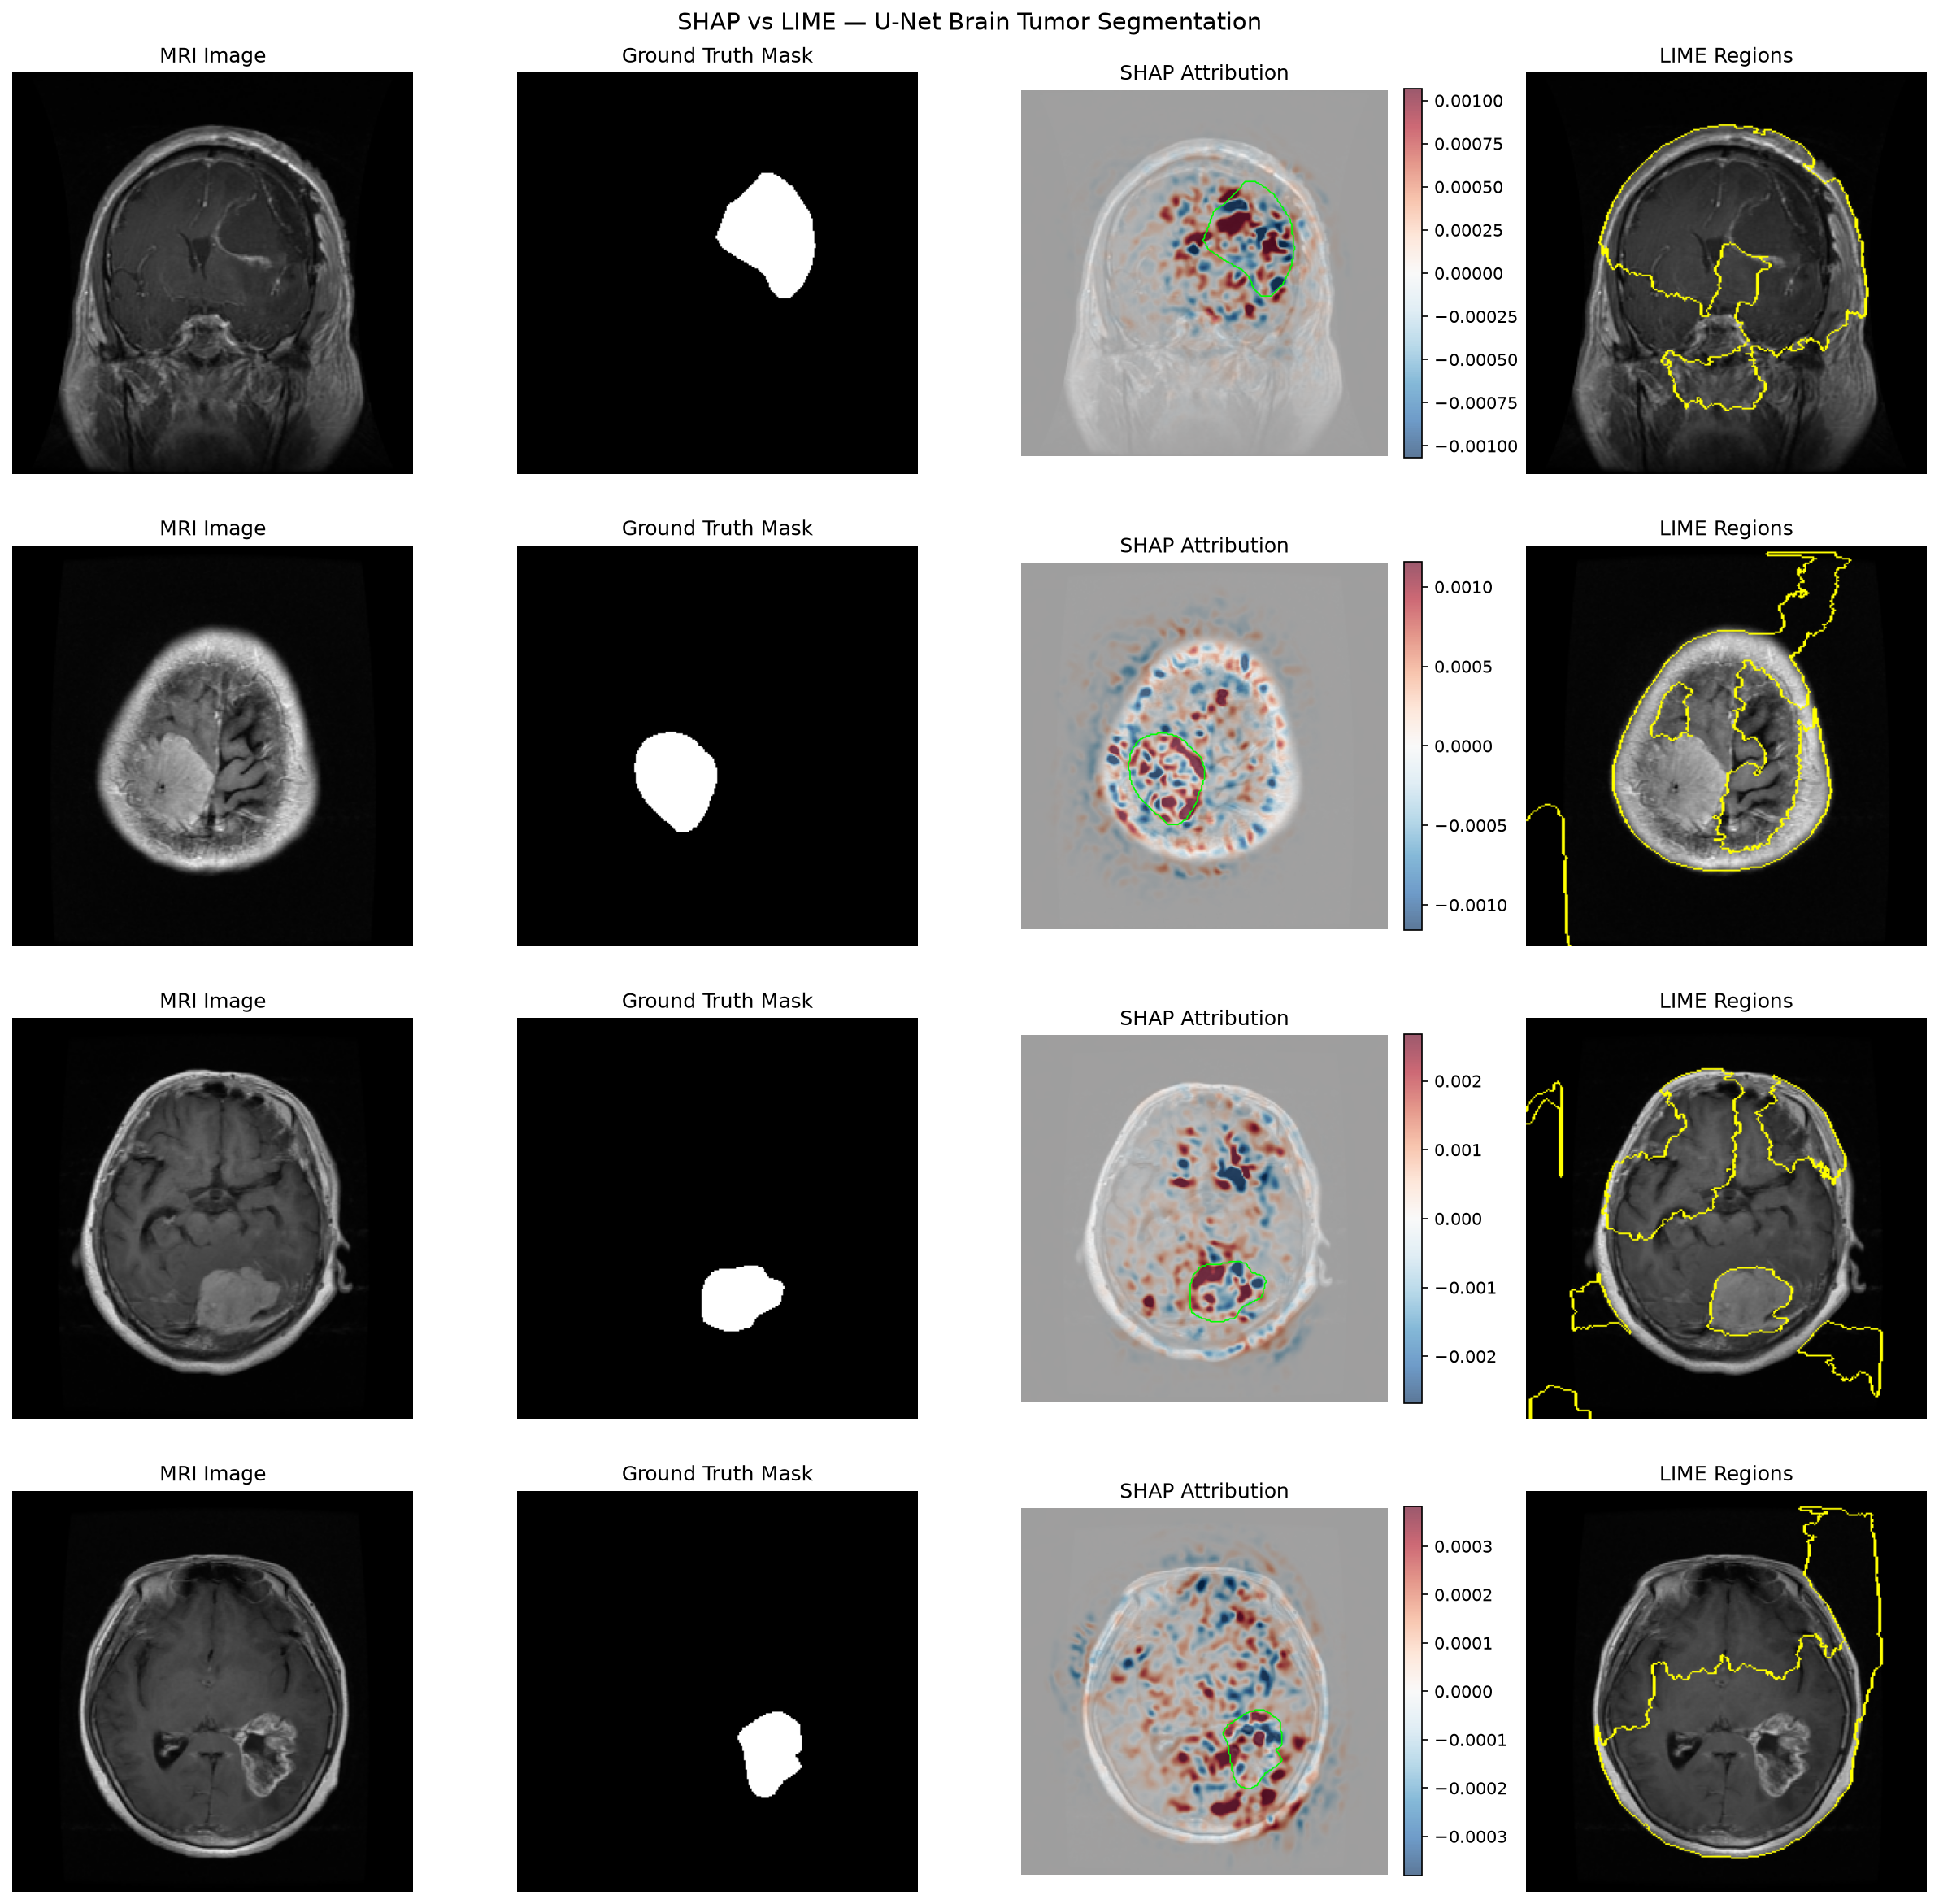

In [11]:
display(Image(filename=os.path.join(BASE_DIR, "reports/shap_vs_lime.png")))